In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("My work has done")

My work has done


## Data collection and sampling

In [2]:
df = pd.read_csv(r"/content/Housing.csv")
print(df)

        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

## Discriptive Statistics

In [5]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Data cleaning Process

In [3]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Finding data types of columns

In [40]:
numeric_df = df.select_dtypes(include=['number'])
print(numeric_df)
Object_df = df.select_dtypes(include=['object'])
print(Object_df)

       price  area  bedrooms  bathrooms  stories  parking
68   6860000  6000         3          1        1        1
74   6650000  4040         3          1        2        1
78   6650000  5700         3          1        1        2
80   6629000  6000         3          1        2        1
84   6510000  3760         3          1        2        2
..       ...   ...       ...        ...      ...      ...
540  1820000  3000         2          1        1        2
541  1767150  2400         3          1        1        0
542  1750000  3620         2          1        1        0
543  1750000  2910         3          1        1        0
544  1750000  3850         3          1        2        0

[350 rows x 6 columns]
    mainroad guestroom basement hotwaterheating airconditioning prefarea  \
68       yes        no       no              no             yes       no   
74       yes        no      yes             yes              no       no   
78       yes       yes      yes              no     

## removing Outliers

In [41]:
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask_numeric = (numeric_df < lower_bound) | (numeric_df > upper_bound)

df = df[~outlier_mask_numeric.any(axis=1)]

print("the shape:",df.shape)

the shape: (349, 13)


## Feature selection

In [21]:
X = ["area", "bedrooms", "bathrooms", "stories", "parking"]
y = ["price"]
print("Done")

Done


In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaler = scaler.fit_transform(df[X])
print(x_scaler)

[[-0.27427952  0.4157549   0.          0.70340224  0.66274283]
 [ 0.81751657  0.4157549   0.         -0.91164633  1.99972114]
 [ 1.01482912  0.4157549   0.          0.70340224  0.66274283]
 ...
 [-0.55051708 -1.17873366  0.         -0.91164633 -0.67423548]
 [-1.01749011  0.4157549   0.         -0.91164633 -0.67423548]
 [-0.39924413  0.4157549   0.          0.70340224 -0.67423548]]


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    x_scaler, df[y], test_size = 0.2, random_state =4
)

## linear regression part

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [32]:
print("\nIntercept", model.intercept_)
print("\nCoefficient", model.coef_)


Intercept [3903355.51673797]

Coefficient [[ 5.04811756e+05  1.20951925e+05 -5.82076609e-11  2.69319087e+05
   1.93226208e+05]]


In [33]:
y_pred = model.predict(X_test)
y_pred

array([[3530029.21086658],
       [5078400.81473891],
       [3939477.79679884],
       [2987284.98383194],
       [3022002.91501968],
       [3181090.6934676 ],
       [3096182.04590121],
       [4494173.27516964],
       [3258202.04396283],
       [3700433.33197747],
       [4205082.75771148],
       [4510528.46276101],
       [3873597.84904092],
       [3347843.71827085],
       [2800033.48638853],
       [3231641.54787157],
       [4561515.66970956],
       [3732694.7415896 ],
       [3928540.02667407],
       [4184744.46761132],
       [3053268.3060284 ],
       [4990959.87032462],
       [4886358.51054749],
       [3477847.429186  ],
       [5151963.47146012],
       [4705434.53734354],
       [4966059.40523907],
       [3002699.01711155],
       [4327783.30410644],
       [4116020.15588009],
       [4739298.19795499],
       [3530968.42136852],
       [5098321.18680736],
       [4517689.87925407],
       [5837717.43126079],
       [4517689.87925407],
       [3826177.77037926],
 

In [34]:
Errors =(y_pred- y_test)
print(Errors)

            price
202 -1.369971e+06
148 -5.215992e+05
387  4.394778e+05
524  6.072850e+05
286 -1.212997e+06
..            ...
244 -2.519555e+05
450  5.271929e+05
144 -1.056168e+06
303 -6.092705e+05
282 -1.016115e+06

[70 rows x 1 columns]


In [36]:
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("mae:", mae)
print("mse:", mse)
print("rmse:", rmse)
print("r2:", r2)

mae: 723823.1580333409
mse: 838594710194.7429
rmse: 915748.16963767
r2: 0.37469783560014314


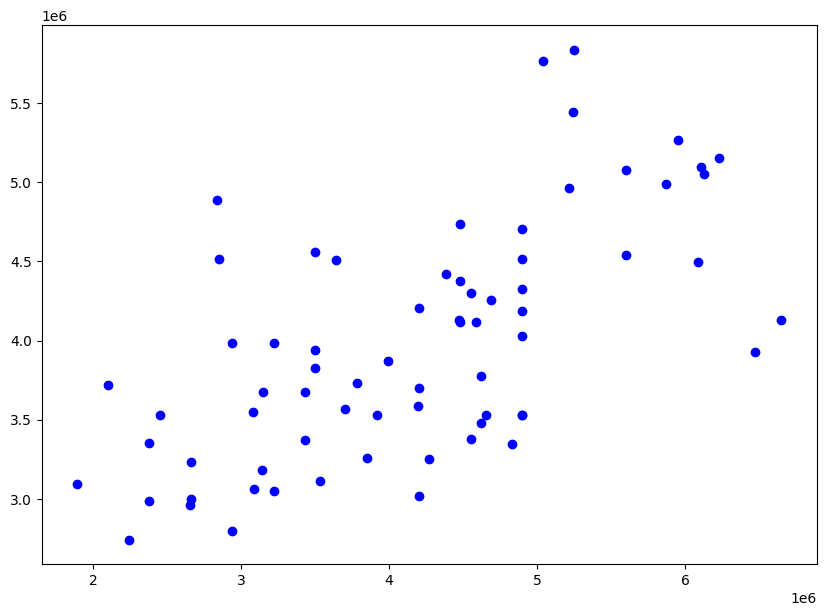

In [48]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,7))

plt.scatter(y_test, y_pred, color='blue', label="Actual Data")
